In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df['label_num'] = df['label'].map({'ham':0, 'spam':1})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label_num'],
    test_size=0.2,
    random_state=42
)

In [7]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9721973094170404


In [9]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.957847533632287


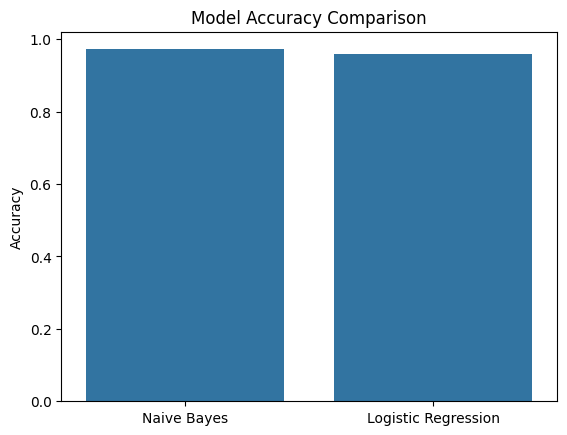

In [10]:
models = ['Naive Bayes','Logistic Regression']
accuracy = [nb_accuracy, lr_accuracy]

sns.barplot(x=models, y=accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

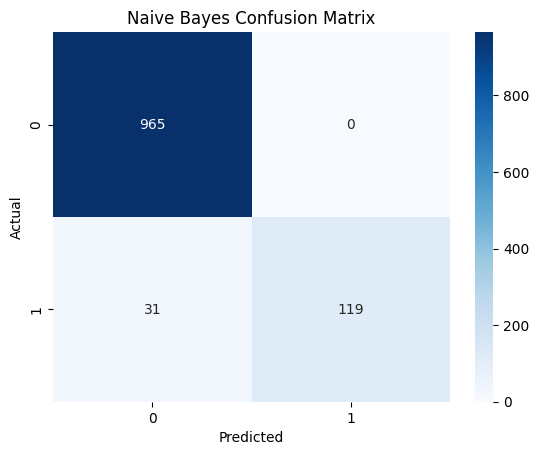

In [11]:
cm_nb = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

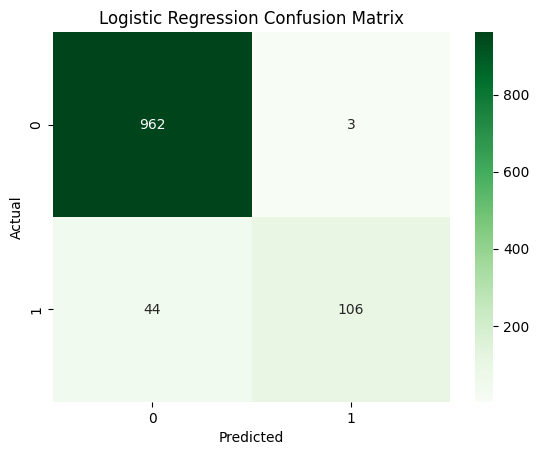

In [12]:
cm_lr = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

top_spam = np.argsort(coefficients)[-20:]
top_ham = np.argsort(coefficients)[:20]

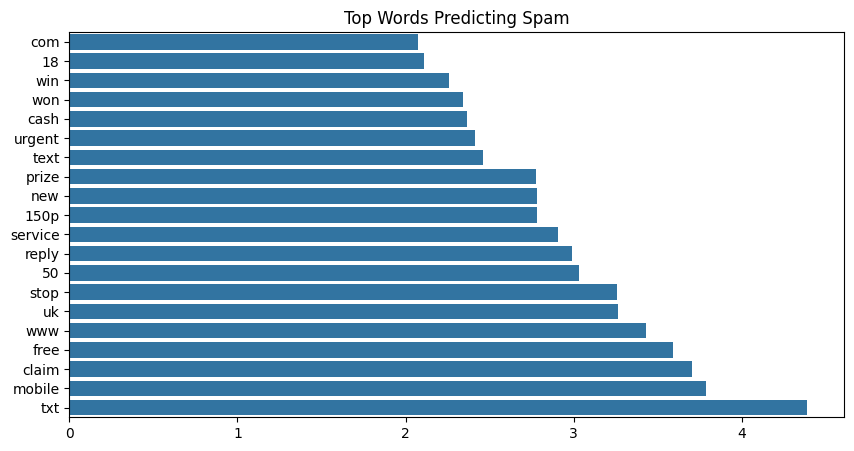

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=coefficients[top_spam],
    y=feature_names[top_spam]
)

plt.title("Top Words Predicting Spam")
plt.show()

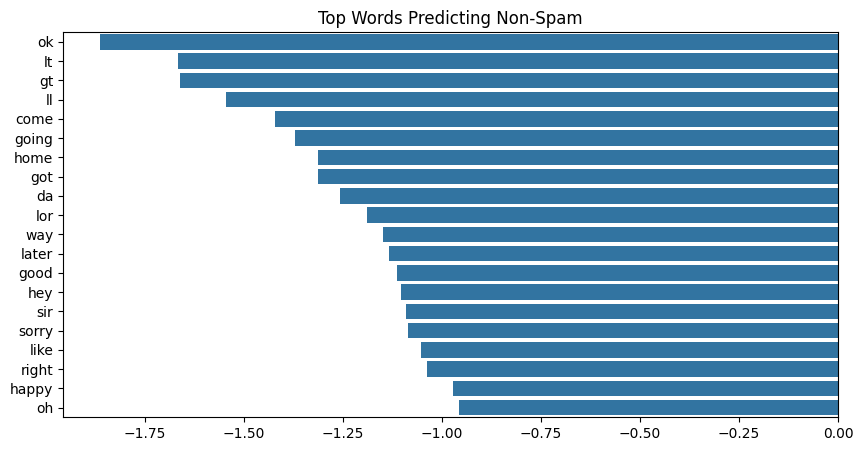

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=coefficients[top_ham],
    y=feature_names[top_ham]
)

plt.title("Top Words Predicting Non-Spam")
plt.show()

In [17]:
def predict_spam(text):

    text_tfidf = vectorizer.transform([text])

    prediction = nb_model.predict(text_tfidf)[0]

    if prediction == 1:
        print("🚨 Spam Email")
    else:
        print("✅ Not Spam")


email = input("Enter an email message:Congratulations! You won a free iPhone. Click now! ")

predict_spam(email)

✅ Not Spam
